In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import os
from dotenv import load_dotenv

In [3]:
load_dotenv()
BASE_PATH = os.getenv("BASE_PATH")
df = pd.read_parquet(f"{BASE_PATH}/data/processed/feature_engineering_clean_delivery_time.parquet")
df.head()

,Distance_m,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7930.0,0,12,1,43,False,False,False,True,False,False,False,False,True
1,16420.0,1,20,2,84,False,False,False,False,True,False,False,False,False
2,9520.0,0,28,1,59,True,False,False,False,False,False,True,False,True
3,7440.0,1,5,1,37,False,True,False,False,False,False,False,False,True
4,19030.0,0,16,5,68,False,False,False,False,False,True,False,False,False


In [5]:
X = df.drop(columns="Delivery_Time_min")
y = df["Delivery_Time_min"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_columns = ['Distance_m', 'Preparation_Time_min', 'Courier_Experience_yrs']

X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[17.17, 5.58, 7. ,...,-1.36, 0.52,-0.93]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Distance_m','Traffic_Level','Preparation_Time_min',..., 'Time_of_Day_Night','Vehicle_Type_Car','Vehicle_Type_Scooter']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,50.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [11]:
y_pred = model.predict(X_test)
print(y_pred)

[ 35.93110419  67.71549138  45.14283399  44.55533486  81.958845
  32.48152753  70.51638825  32.90708276  37.85926028  79.52390325
  75.08569158  61.76509775  36.03289296  72.95756613  90.8824459
  83.86350745  33.20103045  69.52426706  48.19723046  60.53858817
  85.23539096  28.18485907  84.30967221  78.69688613  64.05679242
  33.77837132  86.60821749  25.98490818  51.70803216  67.63359855
  70.41847875  17.21587147  62.61786836  38.0873581   69.07130985
  20.77270538  63.7381474   55.76247732  48.34551681  77.46681234
  77.91135706  31.786183    82.55589778  66.65731604  37.11464456
  15.70295017  92.72288712  85.44238864  80.00259621  27.90628279
  66.44531567  57.62939116  39.44936929  81.32728998  57.21142276
  54.85884503  77.32078398  83.61362055  68.3800564   93.79728679
  49.01506307  36.02387761  51.11712528  49.31086889  52.25229234
  66.86391898  63.63559202  93.77525153  78.47235651  59.71781048
  84.02013082  35.83559932  95.40438948  24.63209396  66.5898386
  61.00786478 

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")

RMSE: 9.00
MAE: 6.15
R2: 0.819


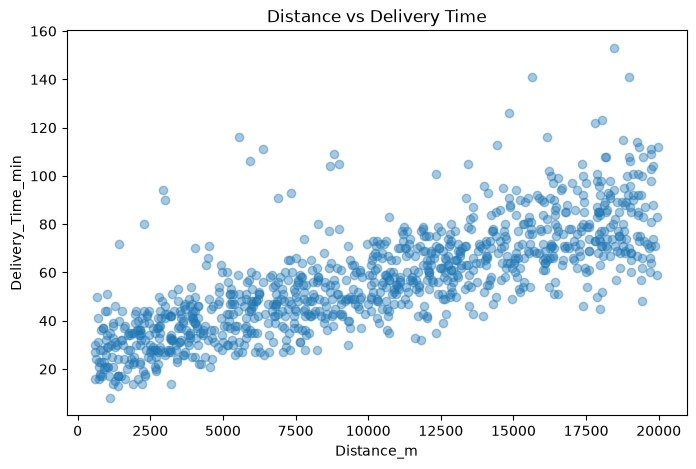

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["Distance_m"], df["Delivery_Time_min"], alpha=0.4)
plt.xlabel("Distance_m")
plt.ylabel("Delivery_Time_min")
plt.title("Distance vs Delivery Time")
plt.show()